# Introduction to dyadic scales
Fourier transforms use linear frequency intervals; multiresolution methods often use geometric frequency intervals. Inherited from ISO3 and music theory (the 12 equal temperament system has order N=12), standardized fractional octave bands have geometric intervals. When these geometric intervals are base 2 [dyadic], they are a good match to computing systems in general and FFTs in particular.

In [42]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from quantum_inferno import qi_debugger
import quantum_inferno.scales_dyadic as qi_scales
print('Module loaded. Epsilon:', qi_scales.get_epsilon())

Module loaded. Epsilon: 2.220446049250313e-16


### Order and harmony
Octaves tones correspond to factors of two in oscillation frequency, and sound harmonious because of their cycle alignment. This is the foundation of music theory and its relation to natural oscillatory systems (such as planetary orbits, tides, etc.), which have sine, cosine, and oscillatory exponential functions as basic building blocks. The 12-tone equal temperament system divides the octave into 12 geometric intervals; 12th order bands. In just intonation the major triad frequencies [notes R, 3, 5 in the major scale] have proportions 4:5:6 and are acoustically consonant as their harmonics resonate. 

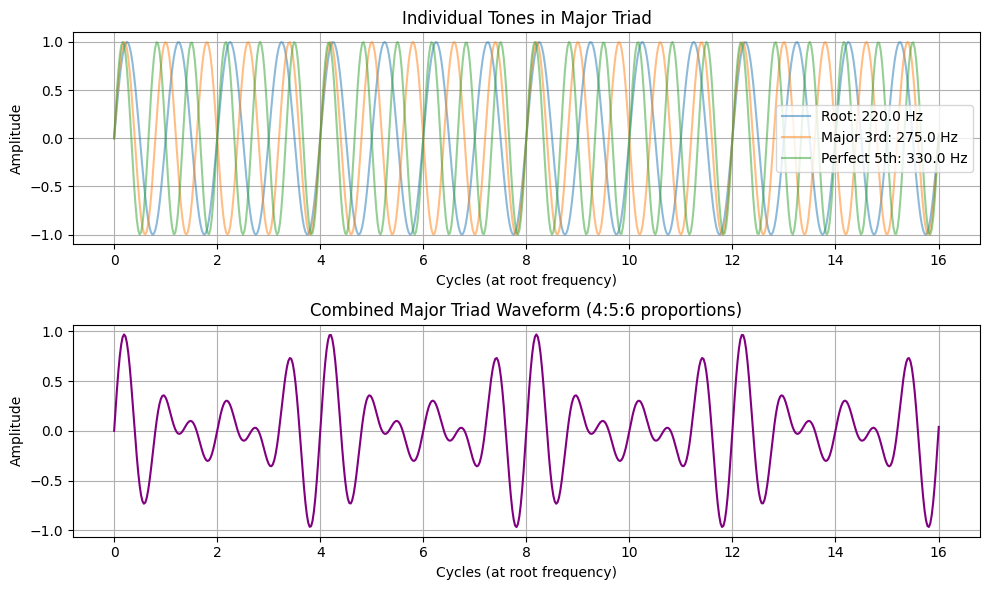

Major triad frequencies:
  Root (R): 220.00 Hz
  Major 3rd: 275.00 Hz
  Perfect 5th: 330.00 Hz
Frequency ratios: 1.0 : 1.25 : 1.50
Ideal ratios: 1.00 : 1.25 : 1.50 (or 4:5:6)


In [43]:
# Construct a major triad sinusoid with proportions 4:5:6
# Using a base frequency and creating the major third and perfect fifth
f_root = 220.0  # A3 (Hz)
f_major_third = f_root * 5/4  # 275 Hz (C#4)
f_perfect_fifth = f_root * 6/4  # 330 Hz (E4)

# Time array
fs = 8000.0  # Sample rate (Hz)
duration = 2.0  # seconds
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

# Generate the three tones
tone_root = np.sin(2 * np.pi * f_root * t)
tone_third = np.sin(2 * np.pi * f_major_third * t)
tone_fifth = np.sin(2 * np.pi * f_perfect_fifth * t)

# Combine into major triad (equal amplitude)
major_triad = (tone_root + tone_third + tone_fifth) / 3

# Convert time to cycles at root frequency
cycles_root = f_root * t

# Plot the waveform (first 16 cycles)
n_cycles = 16
plot_samples = int(n_cycles / f_root * fs) + 2  # +2 to include endpoint
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(cycles_root[:plot_samples], tone_root[:plot_samples], alpha=0.5, label=f'Root: {f_root:.1f} Hz')
plt.plot(cycles_root[:plot_samples], tone_third[:plot_samples], alpha=0.5, label=f'Major 3rd: {f_major_third:.1f} Hz')
plt.plot(cycles_root[:plot_samples], tone_fifth[:plot_samples], alpha=0.5, label=f'Perfect 5th: {f_perfect_fifth:.1f} Hz')
plt.xlabel('Cycles (at root frequency)')
plt.ylabel('Amplitude')
plt.title('Individual Tones in Major Triad')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(cycles_root[:plot_samples], major_triad[:plot_samples], color='purple', linewidth=1.5)
plt.xlabel('Cycles (at root frequency)')
plt.ylabel('Amplitude')
plt.title('Combined Major Triad Waveform (4:5:6 proportions)')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f'Major triad frequencies:')
print(f'  Root (R): {f_root:.2f} Hz')
print(f'  Major 3rd: {f_major_third:.2f} Hz')
print(f'  Perfect 5th: {f_perfect_fifth:.2f} Hz')
print(f'Frequency ratios: {f_root/f_root:.1f} : {f_major_third/f_root:.2f} : {f_perfect_fifth/f_root:.2f}')
print(f'Ideal ratios: 1.00 : 1.25 : 1.50 (or 4:5:6)')

## Cyberspectral space
Physical units are useful anchors to reality. In pattern recognition, they are not necessary. The previous cell can be reconstructed using the sample rate and root frequency as scaling variables, using F440HZ = 440 as the reference frequency, and G2=2 as the base 

In [44]:
# Ensure qi_scales is available in this cell (import if notebook state lost)
import quantum_inferno.scales_dyadic as qi_scales

# Cyberspectral triad (dimensionless cycles, F440 reference, dyadic base 2)

f_base_hz = qi_scales.Slice.F440HZ   # Reference frequency F440HZ
G_base = qi_scales.Slice.G2    # Dyadic base
fs = 8000.0     # Sample rate (Hz)
f_root_hz = f_base_hz / 2  # A3 (Hz), one octave below reference
f_0 = f_root_hz / fs   # fundamental cyberspectral frequency (dimensionless)
proportions = np.array([4,5,6], dtype=float)
ratios = proportions / proportions[0]

# Scaled frequencies
f_root, f_major_third, f_perfect_fifth = f_0*ratios[0], f_0*ratios[1], f_0*ratios[2]
frequencies = np.array([f_root, f_major_third, f_perfect_fifth])

# Dimensionless cycles
duration_cycles = 32
T_total = duration_cycles * f_root
n_samples = int(np.ceil(T_total))
t = np.linspace(0.0, T_total, n_samples, endpoint=False)
tau = f_root * t  # cycles at root

# Synthesis in cyberspectral domain
tone_root = np.sin(2*np.pi*tau)
tone_third = np.sin(2*np.pi*ratios[1]*tau)
tone_fifth = np.sin(2*np.pi*ratios[2]*tau)
major_triad = (tone_root + tone_third + tone_fifth)/3.0

show_cycles = 16
plot_samples = int(show_cycles * f_root)

# Dyadic log2 positions relative to reference
log2_positions = np.log2(frequencies / f_0)

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(tau[:plot_samples], tone_root[:plot_samples], alpha=0.6, label=f'Root {f_root:.0f} (1.00)')
plt.plot(tau[:plot_samples], tone_third[:plot_samples], alpha=0.6, label=f'Major 3rd {f_major_third:.0f} (1.25)')
plt.plot(tau[:plot_samples], tone_fifth[:plot_samples], alpha=0.6, label=f'Perfect 5th {f_perfect_fifth:.0f} (1.50)')
plt.xlabel('Root cycles (dimensionless)')
plt.ylabel('Amplitude')
plt.title('Cyberspectral Components (Cycles Domain)')
plt.grid(True); plt.legend()
plt.subplot(2,1,2)
plt.plot(tau[:plot_samples], major_triad[:plot_samples], color='purple', linewidth=1.2)
plt.xlabel('Root cycles (dimensionless)')
plt.ylabel('Amplitude')
plt.title('Cyberspectral Major Triad 4:5:6')
plt.grid(True)
plt.tight_layout(); plt.show()

print('Cyberspectral triad (just intonation 4:5:6)')
print('Frequencies (Hz):', frequencies.tolist())
print('Ratios:', ratios.tolist())
print('log2(f/f_ref):', log2_positions.tolist())
print('Displayed cycles (root):', show_cycles)

AttributeError: type object 'Slice' has no attribute 'F440HZ'

In [ ]:
# Validate scale order sanitation
orders = [0.5, 0.75, 1.0, 3.0, 6.0, 12.0, -24.0]
sanitized = [qi_scales.scale_order_check(o, show_warning=False) for o in orders]
print('Input orders:', orders)
print('Sanitized orders:', sanitized)
assert all(o >= qi_scales.DEFAULT_SCALE_ORDER_MIN for o in sanitized)

# Cycles <-> Order consistency
for o in [1.0, 3.0, 6.0, 12.0, 24.0]:
    m = qi_scales.cycles_from_order(o)
    o_back = qi_scales.order_from_cycles(m)
    print(f'o={o}, cycles={m:.6f}, back={o_back:.6f}')
    assert np.isclose(o_back, qi_scales.scale_order_check(o))

## Band Intervals (Periods)
Evaluate dyadic band edges and centers for a typical configuration.

In [ ]:
# Configuration
N = qi_scales.Slice.ORD6
G = qi_scales.Slice.G3
ref_s = 1.0
low_s = 0.01
high_s = 1.0
(scale_order, scale_base, n_bands, ref, center_alg, center_geo, start_s, end_s) = qi_scales.band_intervals_periods(
            N, G, ref_s, low_s, high_s, show_warnings=False
        )
print('Bands:', n_bands[:5], '...', n_bands[-5:])
print('Counts:', len(n_bands))
print('First/last center (s):', center_geo[0], center_geo[-1])
# Plot period bands
plt.figure(figsize=(6,3))
plt.plot(n_bands, center_geo, 'o-', label='Geometric center (s)')
plt.xlabel('Band number n')
plt.ylabel('Center period (s)')
plt.grid(True)
plt.legend(); plt.tight_layout()

## Frequency Bands from FFT Points
Replicate expectations similar to `tests/test_scales_dyadic.py`: for a 100 Hz sample and 60 s display, dyadic bands should match expected length and edge values.

In [ ]:
# Parameters mirroring the test case
scale_order0 = 6.0
frequency_sample_hz0 = 100.0
time_display_points_float = qi_scales.DEFAULT_TIME_DISPLAY_S * frequency_sample_hz0
time_display_points_pow2 = int(2 ** np.ceil(np.log2(time_display_points_float)))
physical_frequency_hz = qi_scales.log_frequency_hz_from_fft_points(
            frequency_sample_hz0, time_display_points_pow2,
            scale_order0, qi_scales.Slice.F1HZ, qi_scales.Slice.G3
        )
print('time_display_points_float:', time_display_points_float)
print('time_display_points_pow2:', time_display_points_pow2)
print('log2(pow2):', np.log2(time_display_points_pow2))
print('first freq:', physical_frequency_hz[0])
print('last freq:', physical_frequency_hz[-1])
print('len(freqs):', len(physical_frequency_hz))
# Assertions based on expected values (tolerances for numerical stability)
assert time_display_points_float == 6000.0
assert time_display_points_pow2 == 8192
assert np.isclose(np.log2(time_display_points_pow2), 13.0)
assert np.isclose(physical_frequency_hz[0], 0.1778279410038923, rtol=1e-12, atol=1e-12)
assert np.isclose(physical_frequency_hz[-1], 39.810717055349706, rtol=1e-12, atol=1e-12)
assert len(physical_frequency_hz) == 48
# Plot the frequency bands
plt.figure(figsize=(6,3))
plt.plot(np.arange(len(physical_frequency_hz)), physical_frequency_hz, 'o-')
plt.xlabel('Band index')
plt.ylabel('Frequency (Hz)')
plt.grid(True); plt.tight_layout()

## Frequency Range Conversion
Evaluate `band_frequency_low_high` using a typical audio range to get frequency band edges and centers.

In [ ]:
N = qi_scales.Slice.ORD6
G = qi_scales.Slice.G3
f_ref = qi_scales.Slice.F1HZ
f_low = 20.0   # Hz
f_high = 20000.0  # Hz
fs = 48000.0  # Hz
(N_out, G_out, band_nums, f_ref_out, f_center_alg, f_center_geo, f_start, f_end) = qi_scales.band_frequency_low_high(
            N, G, f_ref, f_low, f_high, fs
        )
print('Order/Base:', N_out, G_out)
print('Bands count:', len(band_nums))
print('First/last center (Hz):', f_center_geo[0], f_center_geo[-1])
# Plot centers in Hz
plt.figure(figsize=(6,3))
plt.plot(band_nums, f_center_geo, 'o-', label='Geometric center (Hz)')
plt.xlabel('Band number')
plt.ylabel('Center frequency (Hz)')
plt.grid(True); plt.legend(); plt.tight_layout()

## Summary
- Order/cycles conversions are consistent.
- Dyadic band intervals computed from periods and frequencies behave as expected.
- Frequency bands from FFT points match the repository's test expectations.